In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd
import seaborn as sns
from hostrada4py import hostradaPoint as hp

## Definition of the location, the time period and download of the HOSTRADA values

In [2]:
# Location in the center of Berlin: 
# Einsteinufer 43 - 53, 10587 Berlin
lon = 13.32259
lat = 52.51712

# Location in the north of Berlin: 
# Ludolfinger Platz, 13465 Berlin 
#lon = 13.28801 
#lat = 52.63248 

# Location about 80 km north of Berlin in the country side:
# Templiner Str 7., 17268 Boitzenburger Land
#lon = 13.60418
#lat = 53.26202

# Time period: entire year 2025
start_UTC = "2025-08-01T00:00"
end_UTC = "2025-08-31T23:00"

df = hp.extract_diffuse_radiation_for_point(
    lon=lon,
    lat=lat,
    start=start_UTC,
    end=end_UTC,
    #apply_weather_correction: bool = True,
)

fn = "HOSTRADA_diffRad.csv"
df.to_csv(fn, index=False)
print(f"{len(df)} rows written to {fn}.")


Load: https://opendata.dwd.de/climate_environment/CDC/grids_germany/hourly/hostrada/radiation_downwelling/rsds_1hr_HOSTRADA-v1-0_BE_gn_2025080100-2025083123.nc
Read: hostrada_cache/rsds_1hr_HOSTRADA-v1-0_BE_gn_2025080100-2025083123.nc
Load: https://opendata.dwd.de/climate_environment/CDC/grids_germany/hourly/hostrada/air_temperature_mean/tas_1hr_HOSTRADA-v1-0_BE_gn_2025080100-2025083123.nc
Read: hostrada_cache/tas_1hr_HOSTRADA-v1-0_BE_gn_2025080100-2025083123.nc
Load: https://opendata.dwd.de/climate_environment/CDC/grids_germany/hourly/hostrada/dew_point/tdew_1hr_HOSTRADA-v1-0_BE_gn_2025080100-2025083123.nc
Read: hostrada_cache/tdew_1hr_HOSTRADA-v1-0_BE_gn_2025080100-2025083123.nc
Load: https://opendata.dwd.de/climate_environment/CDC/grids_germany/hourly/hostrada/humidity_relative/hurs_1hr_HOSTRADA-v1-0_BE_gn_2025080100-2025083123.nc
Read: hostrada_cache/hurs_1hr_HOSTRADA-v1-0_BE_gn_2025080100-2025083123.nc
Load: https://opendata.dwd.de/climate_environment/CDC/grids_germany/hourly/host

## Time series of the calculated diffuse radiation

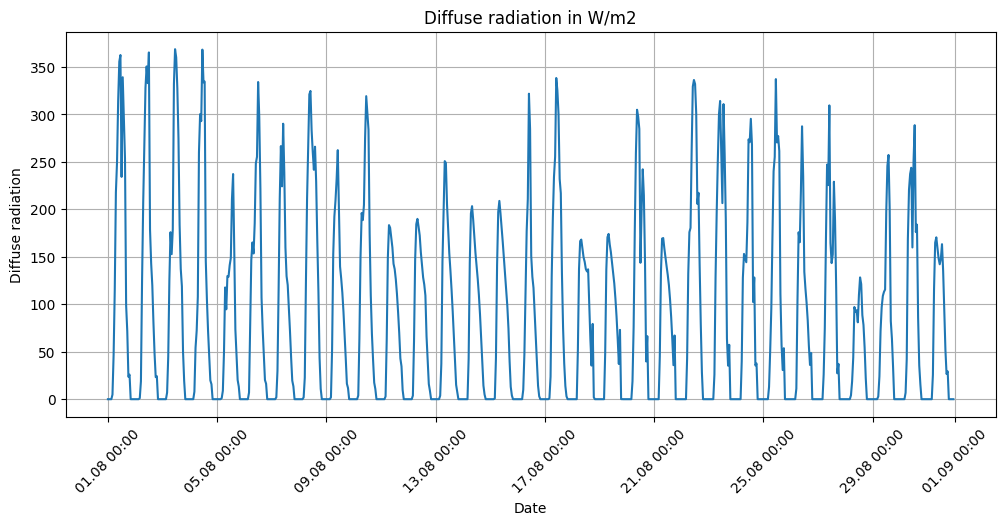

In [3]:
df = pd.read_csv(fn)
df["time"] = pd.to_datetime(df["time"])
df = df.sort_values("time")

fig, ax = plt.subplots(figsize=(12,5))
ax.plot(df["time"], df["dhi"])
ax.set_xlabel("Date")
ax.set_ylabel("Diffuse radiation")

title = "Diffuse radiation in W/m2"

ax.set_title(title)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%d.%m %H:%M"))
ax.xaxis.set_major_locator(mdates.AutoDateLocator())

plt.xticks(rotation=45)
plt.grid(True)
plt.show()
